### Visualization of COVID-19 trends in Toronto

* This script is designed to visualize the trajectory of COVID-19 pandemic in Toronto from January 2020 to December 2024. The original dataset was sourced from the City of Toronto Open Portal [[Monthly Communicable Disease Surveillance Data](https://open.toronto.ca/dataset/monthly-communicable-disease-surveillance-data/)].

* To prepare the data for analysis and plotting, monthly COVID-19 case numbers were manually extracted and consolidated into a simplified csv file named 'covid_per_month.csv'.

* The script reads the processed data, cleans the values, and generates a timeline chart. The primary objective of this visualization is to reveal the temporal patterns, waves, and overall trend of the pandemic within Toronto over the five-year period.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load data
df = pd.read_csv('covid_per_month.csv', usecols=[0,1],
                 names=['Date_str','Cases'], header=0)

# Clean data
df['Cases'] = df['Cases'].str.replace(',', '').astype(int)
df['Date'] = pd.to_datetime(df['Date_str'], format='%b-%y')
print(df.head())

  Date_str  Cases       Date
0   Jan-20      4 2020-01-01
1   Feb-20     14 2020-02-01
2   Mar-20   1884 2020-03-01
3   Apr-20   5727 2020-04-01
4   May-20   4754 2020-05-01


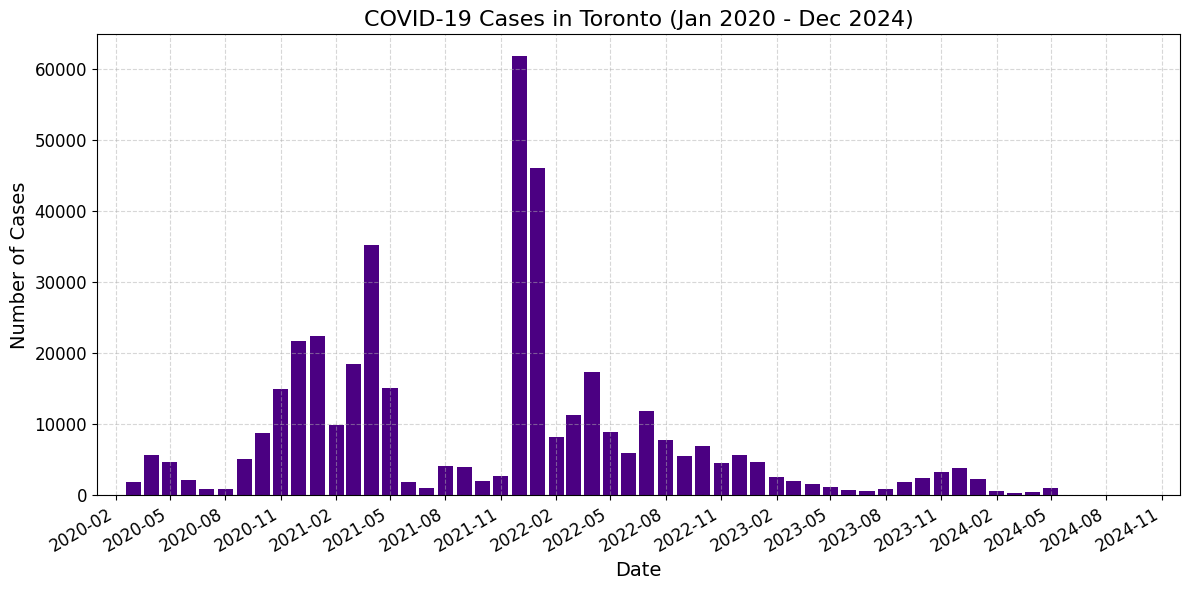

In [ ]:
# Plotting
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(df['Date'], df['Cases'],
        color='indigo',
        width=25) #customize line and marker

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) #format x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) #set interval for x axis
fig.autofmt_xdate() #auto format date labels

# Set x-axis limits
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2024-12-01')
plt.xlim(start_date, end_date)

# Customize plot labels and aesthetics
ax.set_title('COVID-19 Cases in Toronto (Jan 2020 - Dec 2024)', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Number of Cases', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('covid_data_python.png', dpi=300)
plt.show()
